#Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/BANK_CUSTOMER_CHURN_PREDICTION/


/content/drive/MyDrive/BANK_CUSTOMER_CHURN_PREDICTION


In [3]:
!ls

best_model.pkl	     label_encoder_gender.pkl  prediction.ipynb  training.ipynb
Churn_Modelling.csv  onehot_encoder_geo.pkl    scaler.pkl


In [4]:
!pwd

/content/drive/MyDrive/BANK_CUSTOMER_CHURN_PREDICTION


#Import Libraries

In [5]:
!pip install xgboost

In [6]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

# Save Model
import joblib
import pickle

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

## Load Dataset

In [7]:
data=pd.read_csv("Churn_Modelling.csv")
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


 # BANK CUSTOMER CHURN DATASET – COLUMN DESCRIPTION

**ROWNUMBER** – Serial number of the record (not useful for prediction).

**CUSTOMERID** – Unique identification number of the customer.

**SURNAME** – Last name of the customer.

**CREDITSCORE** – Credit rating of the customer (indicates financial reliability).

**GEOGRAPHY** – Country of the customer (France, Germany, Spain).

**GENDER** – Gender of the customer (Male/Female).

**AGE** – Age of the customer.

**TENURE** – Number of years the customer has been with the bank.

**BALANCE** – Current account balance of the customer.

**NUMOFPRODUCTS** – Number of bank products/services used by the customer.

**HASCRCARD** – Indicates whether the customer has a credit card (1 = Yes, 0 = No).

**ISACTIVEMEMBER** – Indicates whether the customer is an active member (1 = Yes, 0 = No).

**ESTIMATEDSALARY** – Estimated annual salary of the customer.

**EXITED** – Target variable indicating churn (1 = Customer left the bank, 0 = Customer stayed).

In [8]:
#description of dataset
data.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [9]:
#missing values
data.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [10]:
#check duplicate values
data.duplicated().sum()


np.int64(0)

#Target Variable Distribution

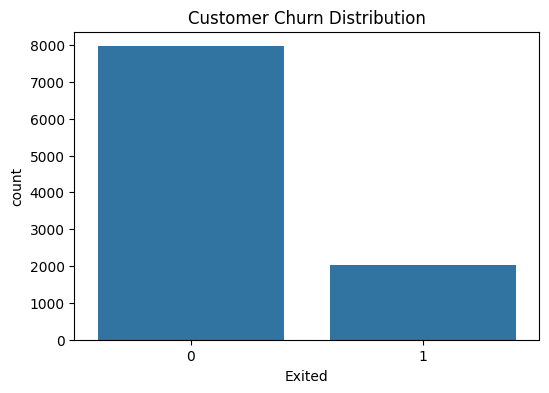

Exited
0    7963
1    2037
Name: count, dtype: int64
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='Exited', data=data)
plt.title("Customer Churn Distribution")
plt.show()

print(data['Exited'].value_counts())
print(data['Exited'].value_counts(normalize=True)*100)

INSIGHT:::The dataset exhibits moderate class imbalance, with non-churn customers significantly outnumbering churn customers (approximately 4:1 ratio), necessitating the use of balancing techniques such as SMOTE.

#AGE VS CHURN

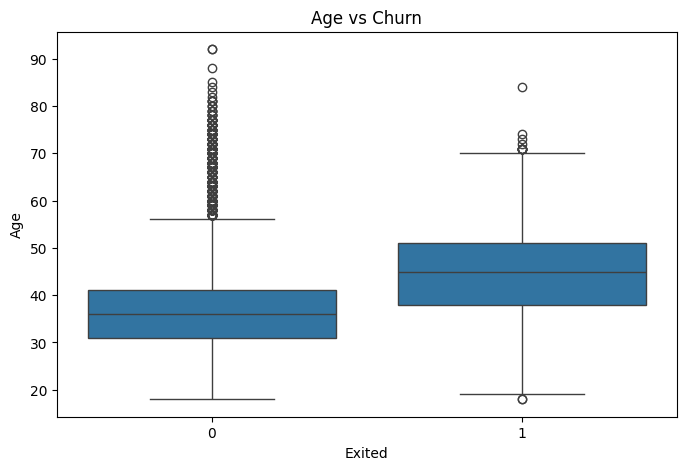

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Exited', y='Age', data=data)
plt.title("Age vs Churn")
plt.show()

#BALANCE VS CHURN

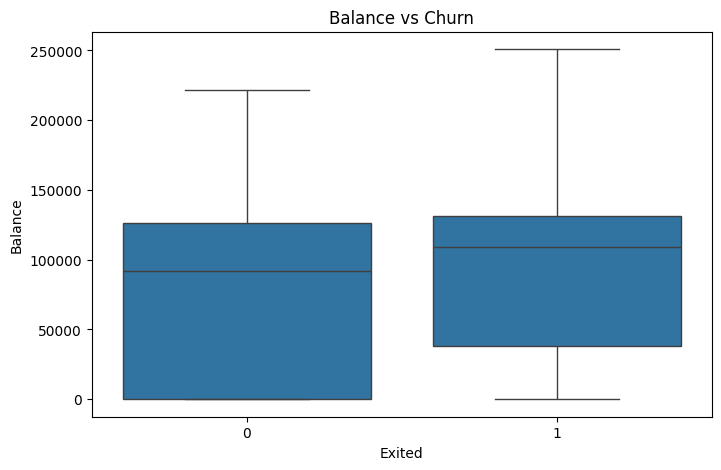

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Exited', y='Balance', data=data)
plt.title("Balance vs Churn")
plt.show()

#GEOGRAPHY VS CHURN

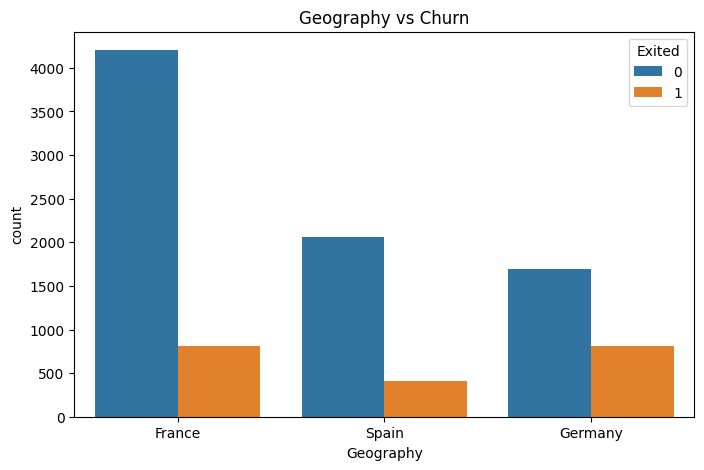

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(x='Geography', hue='Exited', data=data)
plt.title("Geography vs Churn")
plt.show()

#ACTIVE MEMBER VS CHURN

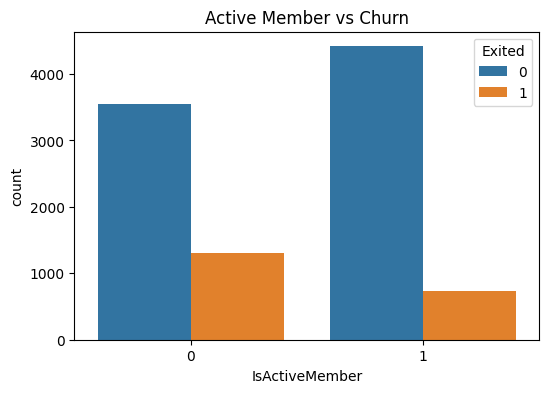

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x='IsActiveMember', hue='Exited', data=data)
plt.title("Active Member vs Churn")
plt.show()

## Preprocess the data

In [16]:
#drop irrevelvent columns
data=data.drop(['RowNumber','CustomerId','Surname'],axis=1)
data

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [17]:
#Encode categorical variables
label_encoder_gender=LabelEncoder()
data['Gender']=label_encoder_gender.fit_transform(data['Gender'])
data

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,0,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0
2,502,France,0,42,8,159660.80,3,1,0,113931.57,1
3,699,France,0,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,1,39,5,0.00,2,1,0,96270.64,0
9996,516,France,1,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,0,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,1,42,3,75075.31,2,1,0,92888.52,1


In [18]:
#one hot encode 'Geography'
from sklearn.preprocessing import OneHotEncoder
onehot_encoder_geo=OneHotEncoder()
geo_encoder=onehot_encoder_geo.fit_transform(data[['Geography']])


In [19]:
onehot_encoder_geo.get_feature_names_out(['Geography'])

array(['Geography_France', 'Geography_Germany', 'Geography_Spain'],
      dtype=object)

In [20]:
geo_encoded_df=pd.DataFrame(geo_encoder.toarray(),columns=onehot_encoder_geo.get_feature_names_out(['Geography']))
geo_encoded_df

,Geography_France,Geography_Germany,Geography_Spain
0,1.0,0.0,0.0
1,0.0,0.0,1.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,0.0,0.0,1.0
...,...,...,...
9995,1.0,0.0,0.0
9996,1.0,0.0,0.0
9997,1.0,0.0,0.0
9998,0.0,1.0,0.0


In [21]:
#combine one hot encoder columns with the original data
data=pd.concat([data.drop('Geography',axis=1),geo_encoded_df],axis=1)
data.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0
3,699,0,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0


In [22]:
#save the encoders
with open('label_encoder_gender.pkl','wb') as file:
    pickle.dump(label_encoder_gender,file)

with open('onehot_encoder_geo.pkl','wb') as file:
    pickle.dump(onehot_encoder_geo,file)

In [23]:
#Divide the dataset into independent and dependent features
X=data.drop('Exited',axis=1)
y=data['Exited']

#split the data
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

#Scale the features
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)


In [24]:
X_train

array([[ 0.35649971,  0.91324755, -0.6557859 , ...,  1.00150113,
        -0.57946723, -0.57638802],
       [-0.20389777,  0.91324755,  0.29493847, ..., -0.99850112,
         1.72572313, -0.57638802],
       [-0.96147213,  0.91324755, -1.41636539, ..., -0.99850112,
        -0.57946723,  1.73494238],
       ...,
       [ 0.86500853, -1.09499335, -0.08535128, ...,  1.00150113,
        -0.57946723, -0.57638802],
       [ 0.15932282,  0.91324755,  0.3900109 , ...,  1.00150113,
        -0.57946723, -0.57638802],
       [ 0.47065475,  0.91324755,  1.15059039, ..., -0.99850112,
         1.72572313, -0.57638802]])

In [25]:
X_train.shape

(8000, 12)

In [26]:
from imblearn.over_sampling import SMOTE
import numpy as np

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE:", np.bincount(y_train_res))


Before SMOTE: [6356 1644]
After SMOTE: [6356 6356]


In [27]:
#save the scaler
with open('scaler.pkl','wb') as file:
    pickle.dump(scaler,file)

## Train Model

#1.Logistic Regression

In [28]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_res, y_train_res)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.721
              precision    recall  f1-score   support

           0       0.91      0.72      0.81      1607
           1       0.39      0.71      0.50       393

    accuracy                           0.72      2000
   macro avg       0.65      0.72      0.65      2000
weighted avg       0.81      0.72      0.75      2000



#2.Decision Tree

In [29]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train_res, y_train_res)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))

print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7705
              precision    recall  f1-score   support

           0       0.88      0.82      0.85      1607
           1       0.43      0.55      0.49       393

    accuracy                           0.77      2000
   macro avg       0.66      0.69      0.67      2000
weighted avg       0.79      0.77      0.78      2000



#3.Random Forest

In [30]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8405
              precision    recall  f1-score   support

           0       0.90      0.90      0.90      1607
           1       0.59      0.61      0.60       393

    accuracy                           0.84      2000
   macro avg       0.75      0.75      0.75      2000
weighted avg       0.84      0.84      0.84      2000



#4.Gradient Boosting

In [31]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(X_train_res, y_train_res)

y_pred_gb = gb.predict(X_test)

print("Gradient Boosting Accuracy:",
      accuracy_score(y_test, y_pred_gb))

print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.8395
              precision    recall  f1-score   support

           0       0.92      0.88      0.90      1607
           1       0.58      0.69      0.63       393

    accuracy                           0.84      2000
   macro avg       0.75      0.78      0.76      2000
weighted avg       0.85      0.84      0.84      2000



#5.XGBoosting

In [32]:
xgb = XGBClassifier(
    random_state=42
)

xgb.fit(X_train_res, y_train_res)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:",
      accuracy_score(y_test, y_pred_xgb))

print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.8545
              precision    recall  f1-score   support

           0       0.90      0.93      0.91      1607
           1       0.65      0.56      0.60       393

    accuracy                           0.85      2000
   macro avg       0.77      0.74      0.76      2000
weighted avg       0.85      0.85      0.85      2000



#Compare Models

In [34]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "Recall":[
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb),
        recall_score(y_test, y_pred_xgb)
    ],
    "Accuracy":[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_dt),
        accuracy_score(y_test,y_pred_rf),
        accuracy_score(y_test,y_pred_gb),
        accuracy_score(y_test,y_pred_xgb)
    ]
})

results.sort_values(
    by=["Recall", "Accuracy"],
    ascending=False
)

,Model,Recall,Accuracy
0,Logistic Regression,0.709924,0.7210
3,Gradient Boosting,0.687023,0.8395
2,Random Forest,0.608142,0.8405
4,XGBoost,0.562341,0.8545
1,Decision Tree,0.552163,0.7705


#INSIGHT::Gradient Boosting performs better among remaining models by comparinf recall and accuracy

#Save the model::Gradient Boosting

In [35]:
import joblib

joblib.dump(gb, 'best_model.pkl')

['best_model.pkl']

In [36]:
!ls

best_model.pkl	     label_encoder_gender.pkl  prediction.ipynb  training.ipynb
Churn_Modelling.csv  onehot_encoder_geo.pkl    scaler.pkl
